In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import sklearn
import os

In [2]:
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_1420016/2215068134.py:25: UserWarning: The palette list

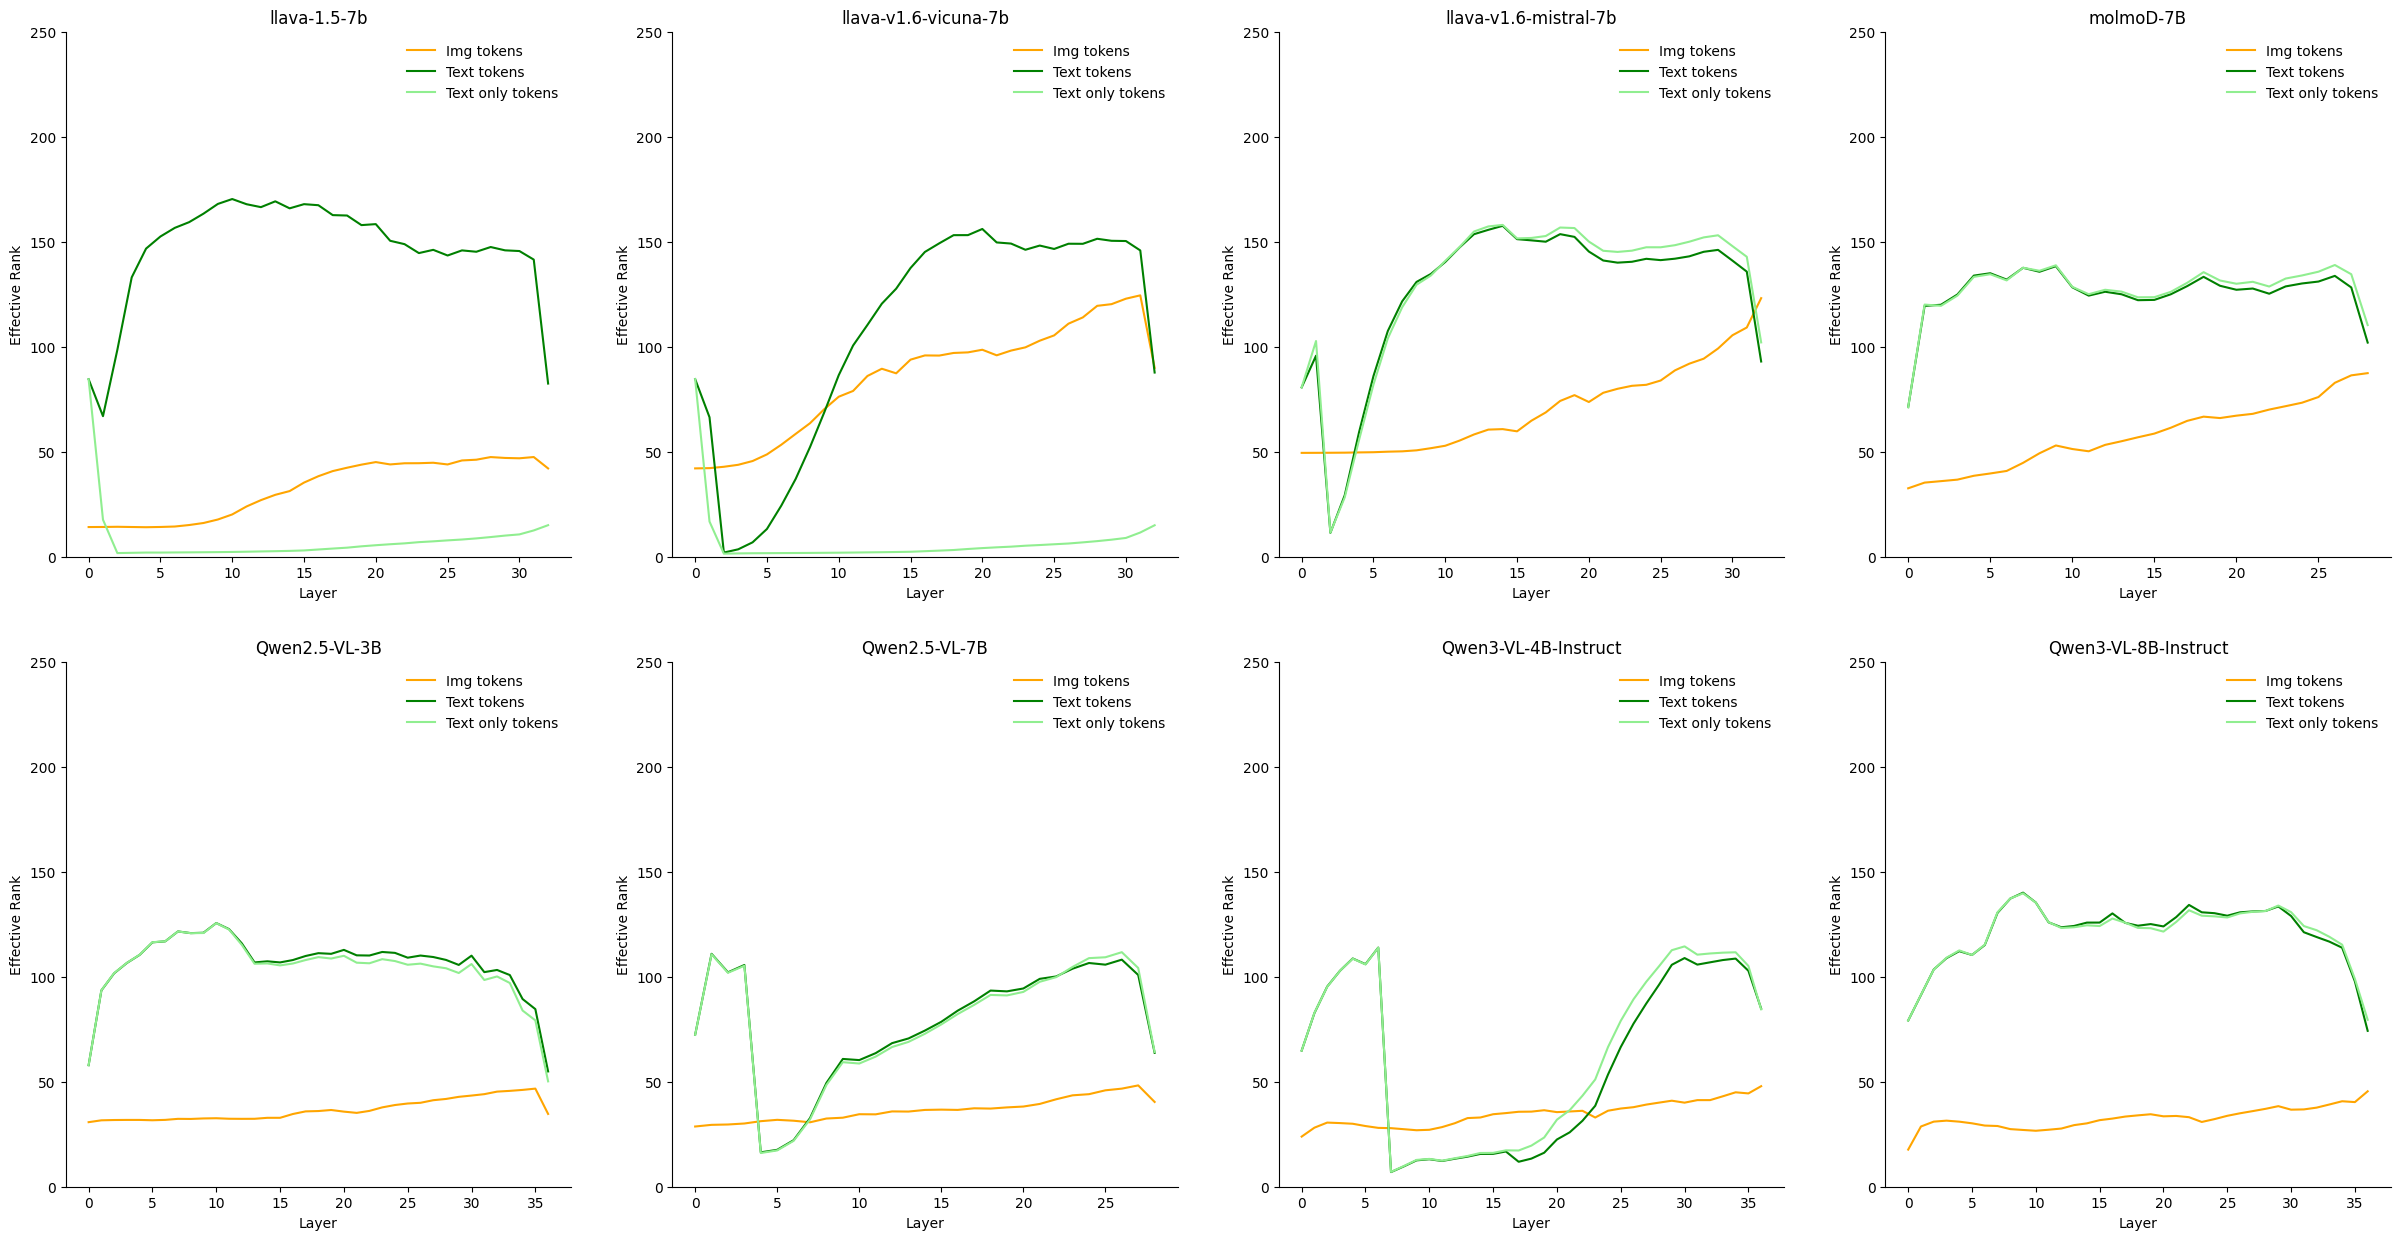

In [3]:
### All together
fig,ax = plt.subplots(2,4,figsize=(30,15))
ax = ax.flatten()

for ax_idx, model in enumerate(model_ls):
    if model=='llava-1.5-7b':
        path = f'{os.getcwd()}/../../results//{model}/svd/token/'
    else:
        path = f'{os.getcwd()}/../../results//{model}/svd/'

    files = [f for f in os.listdir(path) if 'ScienceQA' in f]
    plot_df = []

    for idx, f in enumerate(files):
        df_ = pd.read_csv(path+f, index_col=0)
        if 'label' in df_.columns or 'sample' in df_.columns:
            df_ = df_.drop(['label','sample'],axis=1)

        df_ = df_.melt(['Mean over'])
        df_['layers'] = df_['variable'].astype(int)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
        
        
    b = sns.lineplot(
        data=plot_df[(plot_df['Mean over']!='All tokens') & (plot_df['Mean over']!='Image only tokens')],
        # data=plot_df,
        x='layers',
        y='value',
        hue='Mean over',
        palette=['orange','green', 'lightgreen', 'red'],
        err_style='band',
        errorbar=lambda x: (x.min(), x.max()),
        ax=ax[ax_idx]
    )

    b.set(ylim=(0,250))
    b.set_xlabel('Layer')
    b.set_ylabel('Effective Rank')
    b.set_title(f'{model if model!="llava7B" else "llava1.5"}')
    b.legend(frameon=False)

sns.despine(top=True, right=True)



In [4]:
auc_ls = []
for ax_idx, model in enumerate(model_ls):
    if model=='llava-1.5-7b':
        path = f'{os.getcwd()}/../../results//{model}/svd/token/'
    else:
        path = f'{os.getcwd()}/../../results//{model}/svd/'

    files = [f for f in os.listdir(path) if 'ScienceQA' in f]

    plot_df = []

    for idx, f in enumerate(files):
        df_ = pd.read_csv(path+f, index_col=0)
        if 'label' in df_.columns or 'sample' in df_.columns:
            df_ = df_.drop(['label','sample'],axis=1)

        df_ = df_.melt(['Mean over'])
        df_['layers'] = df_['variable'].astype(int)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["Mean over", "layers"]).mean(numeric_only=True).reset_index()
    auc_text = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Text tokens']['layers']/mean_df['layers'].max(), 
                                mean_df[mean_df['Mean over']=='Text tokens']['value'])

    auc_img = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Img tokens']['layers']/mean_df['layers'].max(), 
                                mean_df[mean_df['Mean over']=='Img tokens']['value'])
    print(f"{model}: ", auc_text-auc_img)
    auc_ls = auc_ls + [auc_text-auc_img]


llava-1.5-7b:  115.86675803125001
llava-v1.6-vicuna-7b:  21.587552162500018
llava-v1.6-mistral-7b:  57.56488579687499
molmoD-7B:  69.50049303571429
Qwen2.5-VL-3B:  71.09818824999999
Qwen2.5-VL-7B:  41.20671655357143
Qwen3-VL-4B-Instruct:  23.670948866666663
Qwen3-VL-8B-Instruct:  89.25360730555556


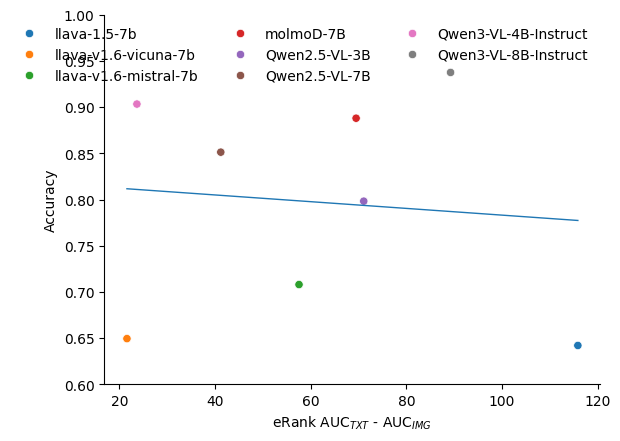

In [5]:
acc_ls = [
    0.6420426375805652, 
    0.6494794248884482, 
    0.7079821517104611, 
    0.888, 
    0.7982151710461081, 
    0.8512642538423401, 
    0.903321764997521, 
    0.9375309866137829
]

plot_df = pd.DataFrame({
    'model': model_ls,
    'Accuracy': acc_ls,
    'AUC': auc_ls
})


size_ls = ['7B', '7B', '7B', '4B', '3B', '7B']

b = sns.scatterplot(data=plot_df, x='AUC', y='Accuracy', hue='model')
sns.regplot(data=plot_df, x="AUC", y="Accuracy", ci=None,
            scatter=False, ax=b, line_kws={"lw":1})

b.legend(frameon=False, ncols=3)
b.set(ylim=(0.6,1))
b.set_ylabel('Accuracy')
b.set_xlabel('eRank AUC$_{TXT}$ - AUC$_{IMG}$')
sns.despine(top=True, right=True)



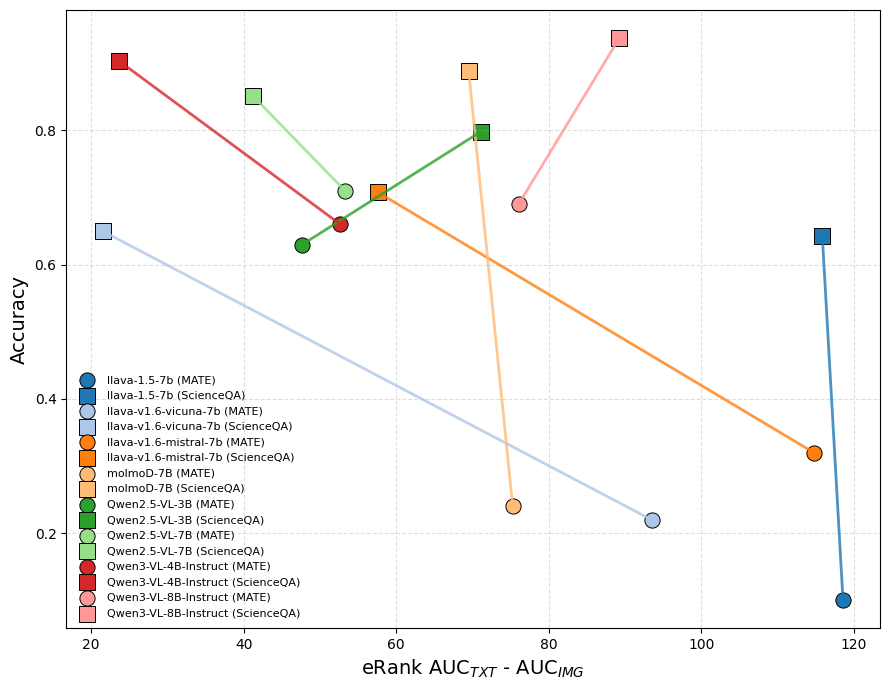

In [12]:

# llava1.5:  118.57788467415473
# llava1.6_vicuna:  93.47599844453124
# llava1.6_mistral:  114.76172467968749
# molmoD-7B:  68.26799382142858
# qwen2.5_3B:  47.66852175555554
# qwen2.5_7B:  53.30485114017856
# Qwen3-VL-4B-Instruct:  52.68553216597221
# Qwen3-VL-8B-Instruct:  76.03866390902778
# Qwen3-VL-4B-Thinking:  76.74591481222222
# Qwen3-VL-8B-Thinking:  80.92830570361113

df = pd.DataFrame({
    'dataset': ['ScienceQA']*len(model_ls) + ['MATE']*len(model_ls),
    'models': model_ls*2,
    'accuracy': acc_ls + [
        0.1, 0.22, 0.32, 0.24, 0.63, 0.71, 0.66, 0.69
    ],
    'auc': auc_ls + [
        118.57788467415473, 
        93.47599844453124, 
        114.76172467968749,  
        75.2679938214285, 
        47.66852175555554, 
        53.30485114017856, 
        52.68553216597221, 
        76.03866390902778]
})

# Unique colors per model
import matplotlib.cm as cm
models = df["models"].unique()
colors = {m: cm.tab20(i % 20) for i, m in enumerate(models)}

# Markers per dataset
markers = {
    "MATE": "o",        # circle
    "ScienceQA": "s"    # square
}

plt.figure(figsize=(9, 7))

# Plot points and connect same-model points
for model in models:
    sub = df[df["models"] == model].sort_values("dataset")

    # Scatter each dataset point separately (for markers)
    for _, row in sub.iterrows():
        plt.scatter(
            row["auc"],
            row["accuracy"],
            color=colors[model],
            marker=markers[row["dataset"]],
            s=120,
            edgecolors="black",
            linewidth=0.7,
            label=f"{model} ({row['dataset']})"
        )

    # Connect the dots belonging to the same model
    if len(sub) > 1:
        plt.plot(
            sub["auc"],
            sub["accuracy"],
            color=colors[model],
            linewidth=2,
            alpha=0.8
        )

plt.xlabel("eRank AUC$_{TXT}$ - AUC$_{IMG}$", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
# plt.title("Accuracy vs diff AUC", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.4)

# Avoid duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys(),frameon=False, ncol=1, fontsize=8)

plt.tight_layout()
plt.show()